# 🖼️ TP — Image Captioning avec CNN + RNN (LSTM / GRU / Transformer)
### Flickr8k Dataset · PyTorch · Google Colab

---
**Architecture :**  CNN Encoder (ResNet50) → RNN Decoder (LSTM / GRU) / Transformer Decoder

**Dataset Google Drive :**
```
/content/drive/MyDrive/Flickr8k/
    ├── Images/          ← 8 000 images .jpg
    └── captions.txt     ← format : image#N\tcaption
```

**Tous les résultats sont sauvegardés automatiquement dans :**
```
/content/drive/MyDrive/Flickr8k_Output/
    ├── models/          ← encodeur & décodeur (.pkl)
    ├── logs/            ← training_log.txt + history JSON
    ├── results/         ← captions générées + images annotées
    └── plots/           ← courbes de loss
```


---
## 📦 Partie 1 — Préparation du Dataset

### 1.1 Installation des bibliothèques

In [ ]:
!pip install -q torch torchvision tqdm Pillow nltk
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
print("✅ Bibliothèques installées")


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


✅ Bibliothèques installées


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


### 1.2 Imports & configuration

In [ ]:
import os, re, math, string, pickle, json, random, time
from pathlib import Path
from collections import Counter

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.utils.data as data
import torch.optim as optim
import torchvision.transforms as transforms
import torchvision.models as models
from torch.utils.data import Dataset, DataLoader
from nltk.tokenize import word_tokenize

# ── Reproductibilité ────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"🖥️  Device : {DEVICE}")
print(f"🔥 PyTorch : {torch.__version__}")


🖥️  Device : cuda
🔥 PyTorch : 2.10.0+cu128


### 1.3 Montage Google Drive & dossiers de sortie

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ── Chemins ─────────────────────────────────────────────────────
DRIVE_ROOT    = Path('/content/drive/MyDrive')
DATA_DIR      = DRIVE_ROOT / 'archive'
IMAGES_DIR    = DATA_DIR   / 'Images'
CAPTIONS_FILE = DATA_DIR   / 'captions.txt'

OUT_ROOT    = DRIVE_ROOT / 'Flickr8k_Output'
MODELS_DIR  = OUT_ROOT / 'models'
LOGS_DIR    = OUT_ROOT / 'logs'
RESULTS_DIR = OUT_ROOT / 'results'
SAMPLES_DIR = RESULTS_DIR / 'sample_outputs'
PLOTS_DIR   = OUT_ROOT / 'plots'

for d in [MODELS_DIR, LOGS_DIR, RESULTS_DIR, SAMPLES_DIR, PLOTS_DIR]:
    d.mkdir(parents=True, exist_ok=True)
    print(f"✅ {d}")


✅ /content/drive/MyDrive/Flickr8k_Output/models
✅ /content/drive/MyDrive/Flickr8k_Output/logs
✅ /content/drive/MyDrive/Flickr8k_Output/results
✅ /content/drive/MyDrive/Flickr8k_Output/results/sample_outputs
✅ /content/drive/MyDrive/Flickr8k_Output/plots


 1.4 Chargement & nettoyage des captions

In [ ]:
import string
import pickle
from pathlib import Path

# --- AJOUT CRUCIAL : Vérification du séparateur ---
# La plupart des versions de Flickr8k utilisent ',' au lieu de '\t'
# Ce petit hack permet de s'adapter sans changer votre fonction load_captions
# --------------------------------------------------

def load_captions(path: Path) -> dict:
    """
    Lit captions.txt (format : image#N\tcaption)
    """
    captions = {}
    table = str.maketrans('', '', string.punctuation)
    with open(path, 'r') as f:
        # Si votre fichier est un CSV (virgules), on remplace dynamiquement pour votre logique
        content = f.read().replace(',', '\t')

    for line in content.splitlines():
        line = line.strip()
        # On saute l'en-tête si elle existe (image\tcaption)
        if not line or '\t' not in line or line.startswith('image'):
            continue

        img, caption = line.split('\t', 1)
        img     = img.split('#')[0].strip()
        caption = caption.lower().translate(table).strip()
        caption = "startseq " + caption + " endseq"
        captions.setdefault(img, []).append(caption)
    return captions

# --- TEST ET AFFICHAGE ---
print("📂 Chargement des captions …")
all_captions = load_captions(CAPTIONS_FILE)

if not all_captions:
    print("❌ Erreur : Aucune image chargée. Vérifiez le chemin ou le format du fichier.")
else:
    print(f"✅ {len(all_captions):,} images chargées")
    print("🔍 Exemple :", list(all_captions.items())[0])

📂 Chargement des captions …
✅ 8,091 images chargées
🔍 Exemple : ('1000268201_693b08cb0e.jpg', ['startseq a child in a pink dress is climbing up a set of stairs in an entry way endseq', 'startseq a girl going into a wooden building endseq', 'startseq a little girl climbing into a wooden playhouse endseq', 'startseq a little girl climbing the stairs to her playhouse endseq', 'startseq a little girl in a pink dress going into a wooden cabin endseq'])


### 1.5 Construction du vocabulaire

In [ ]:
# ── Construction du vocabulaire (approche TP) ───────────────────
vocab_set = set()
for img_caps in all_captions.values():
    for c in img_caps:
        vocab_set.update(word_tokenize(c))

word2idx = {w: i + 1 for i, w in enumerate(sorted(vocab_set))}
word2idx["<pad>"] = 0
idx2word = {i: w for w, i in word2idx.items()}
vocab_size = len(word2idx)
print(f"📚 Taille du vocabulaire : {vocab_size:,} mots")

# Indices spéciaux
PAD_IDX = word2idx["<pad>"]
SOS_IDX = word2idx.get("startseq", 1)
EOS_IDX = word2idx.get("endseq",   2)

# ── Sauvegarde du vocabulaire ────────────────────────────────────
vocab_path = OUT_ROOT / 'vocabulary.pkl'
with open(vocab_path, 'wb') as f:
    pickle.dump({'word2idx': word2idx, 'idx2word': idx2word}, f)
print(f"💾 Vocabulaire sauvegardé → {vocab_path}")


📚 Taille du vocabulaire : 8,830 mots
💾 Vocabulaire sauvegardé → /content/drive/MyDrive/Flickr8k_Output/vocabulary.pkl


### 1.6 Split Train / Val / Test (80/10/10)

In [ ]:
all_images = list(all_captions.keys())
random.shuffle(all_images)
n = len(all_images)
train_imgs = set(all_images[:int(0.80 * n)])
val_imgs   = set(all_images[int(0.80 * n):int(0.90 * n)])
test_imgs  = set(all_images[int(0.90 * n):])
print(f"📊 Train={len(train_imgs)} | Val={len(val_imgs)} | Test={len(test_imgs)}")


📊 Train=6472 | Val=809 | Test=810


### 1.7 Transformations des images

In [ ]:
transform_train = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.1, contrast=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225)),
])

transform_test = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406),
                         (0.229, 0.224, 0.225)),
])
print("✅ Transformations définies")


✅ Transformations définies


### 1.8 Dataset & DataLoader

In [ ]:
class FlickrDataset(Dataset):
    """
    Un sample = (image_tensor, caption_tensor).
    Une caption par ligne (5 captions × N images = 5N lignes).
    """
    def __init__(self, image_names, captions_dict,
                 images_dir, word2idx, transform=None):
        self.images_dir = Path(images_dir)
        self.word2idx   = word2idx
        self.transform  = transform
        self.data = []
        for img in image_names:
            for cap in captions_dict.get(img, []):
                tokens = word_tokenize(cap)
                ids    = [word2idx.get(w, PAD_IDX) for w in tokens]
                self.data.append((img, ids))

    def __len__(self): return len(self.data)

    def __getitem__(self, idx):
        img_name, ids = self.data[idx]
        image = Image.open(self.images_dir / img_name).convert('RGB')
        if self.transform:
            image = self.transform(image)
        return image, torch.tensor(ids, dtype=torch.long)

    # Méthode utilisée par le TP pour l'échantillonnage par longueur
    def get_train_indices(self):
        lengths = [len(ids) for _, ids in self.data]
        target  = random.choice(lengths)
        return [i for i, (_, ids) in enumerate(self.data)
                if len(ids) == target]


def collate_fn(batch):
    """Padding des captions à la même longueur dans un batch."""
    images, captions = zip(*batch)
    images  = torch.stack(images, 0)
    lengths = [len(c) for c in captions]
    padded  = torch.full((len(captions), max(lengths)),
                          PAD_IDX, dtype=torch.long)
    for i, cap in enumerate(captions):
        padded[i, :len(cap)] = cap
    return images, padded


def get_loader(image_set, batch_size=64, train=True):
    ds = FlickrDataset(image_set, all_captions, IMAGES_DIR,
                       word2idx,
                       transform=transform_train if train else transform_test)
    return DataLoader(ds, batch_size=batch_size,
                      shuffle=train, collate_fn=collate_fn,
                      num_workers=2, pin_memory=True)


train_loader = get_loader(train_imgs, batch_size=64, train=True)
val_loader   = get_loader(val_imgs,   batch_size=64, train=False)
test_loader  = get_loader(test_imgs,  batch_size=1,  train=False)
print(f"✅ DataLoaders créés")
print(f"   train={len(train_loader.dataset):,} | "
      f"val={len(val_loader.dataset):,} | "
      f"test={len(test_loader.dataset):,} samples")


✅ DataLoaders créés
   train=32,360 | val=4,045 | test=4,050 samples


---
## 🧠 Partie 2 — Architecture du Modèle

### 2.1 Encodeur CNN (ResNet50 pré-entraîné)

In [ ]:
class EncoderCNN(nn.Module):
    """
    ResNet50 pré-entraîné dont la dernière couche FC est remplacée
    par une projection linéaire vers embed_size.
    Les paramètres du backbone sont gelés.
    """
    def __init__(self, embed_size: int, backbone: str = 'resnet50'):
        super().__init__()
        resnet = getattr(models, backbone)(pretrained=True)
        # Désactiver l'apprentissage du backbone
        for param in resnet.parameters():
            param.requires_grad_(False)
        # Retirer la dernière couche de classification
        modules = list(resnet.children())[:-1]
        self.resnet = nn.Sequential(*modules)
        self.embed  = nn.Linear(resnet.fc.in_features, embed_size)
        self.bn     = nn.BatchNorm1d(embed_size)

    def forward(self, images):
        features = self.resnet(images)            # (B, 2048, 1, 1)
        features = features.view(features.size(0), -1)  # (B, 2048)
        features = self.embed(features)           # (B, embed_size)
        return self.bn(features)

print("✅ EncoderCNN défini")


✅ EncoderCNN défini


### 2.2 Décodeur RNN (LSTM ou GRU)

In [ ]:
class DecoderRNN(nn.Module):
    """
    Embedding → LSTM (ou GRU) → Linear → scores vocabulaire.

    La feature image est concaténée en tête de la séquence
    d'embeddings (comme dans le TP original).
    """
    def __init__(self, embed_size: int, hidden_size: int,
                 vocab_size: int, num_layers: int = 1,
                 dropout: float = 0.0, rnn_type: str = 'lstm'):
        super().__init__()
        self.hidden_dim = hidden_size
        self.rnn_type   = rnn_type

        # Couche d'embedding
        self.embed = nn.Embedding(vocab_size, embed_size,
                                  padding_idx=PAD_IDX)
        self.drop  = nn.Dropout(dropout)

        # LSTM ou GRU
        rnn_cls    = nn.LSTM if rnn_type == 'lstm' else nn.GRU
        self.lstm  = rnn_cls(embed_size, hidden_size,
                             num_layers=num_layers,
                             dropout=dropout if num_layers > 1 else 0,
                             batch_first=True)
        # Couche linéaire finale
        self.linear = nn.Linear(hidden_size, vocab_size)

        # État caché initial (mis à jour durant l'inférence)
        self.hidden = (torch.zeros(1, 1, hidden_size),
                       torch.zeros(1, 1, hidden_size))

    def forward(self, features, captions):
        """
        features : (B, embed_size)
        captions  : (B, T)   → on retire le dernier token (<end>)
        Retourne  : logits (B, T, vocab_size)
        """
        # Embedding des captions (sans le dernier token)
        cap_embedding = self.drop(self.embed(captions[:, :-1]))   # (B,T-1,E)
        # Concaténer la feature image en tête
        embeddings = torch.cat(
            (features.unsqueeze(1), cap_embedding), dim=1)        # (B,T,E)
        lstm_out, self.hidden = self.lstm(embeddings)              # (B,T,H)
        outputs = self.linear(lstm_out)                            # (B,T,V)
        return outputs
    @torch.no_grad()
    def sample(self, inputs, states=None, max_len: int = 20) -> list:
        """
        Génère une caption mot par mot (décodage greedy).
        inputs : (1, 1, embed_size) — feature image
        """
        self.eval()
        res = []
        for _ in range(max_len):
            lstm_out, states = self.lstm(inputs, states)        # (1,1,H)
            outputs  = self.linear(lstm_out.squeeze(1))         # (1,V)
            _, pred  = outputs.max(dim=1)
            idx      = pred.item()
            res.append(idx)
            if idx == EOS_IDX:
                break
            inputs = self.drop(self.embed(pred)).unsqueeze(1)   # (1,1,E)
        return res

print("✅ DecoderRNN (LSTM/GRU) défini")


✅ DecoderRNN (LSTM/GRU) défini


### 2.3 Décodeur Transformer (Travail supplémentaire 🎁)

In [ ]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model: int, max_len: int = 512, dropout: float = 0.1):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe  = torch.zeros(max_len, d_model)
        pos = torch.arange(0, max_len).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float()
                        * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x):
        return self.dropout(x + self.pe[:, :x.size(1)])


class TransformerCaptionDecoder(nn.Module):
    """
    nn.TransformerDecoder conditionné sur la feature CNN
    (traitée comme un token mémoire unique).
    """
    def __init__(self, embed_size: int, vocab_size: int,
                 num_heads: int = 8, num_layers: int = 3,
                 ff_dim: int = 2048, dropout: float = 0.1):
        super().__init__()
        self.embed   = nn.Embedding(vocab_size, embed_size, padding_idx=PAD_IDX)
        self.pos_enc = PositionalEncoding(embed_size, dropout=dropout)
        layer        = nn.TransformerDecoderLayer(
            embed_size, num_heads, ff_dim, dropout, batch_first=True)
        self.transformer = nn.TransformerDecoder(layer, num_layers)
        self.fc = nn.Linear(embed_size, vocab_size)

    def _causal_mask(self, sz, device):
        return torch.triu(torch.ones(sz, sz, device=device), diagonal=1).bool()

    def forward(self, features, captions):
        memory   = features.unsqueeze(1)                          # (B,1,E)
        tgt      = self.pos_enc(self.embed(captions[:, :-1]))     # (B,T-1,E)
        mask     = self._causal_mask(tgt.size(1), tgt.device)
        pad_mask = (captions[:, :-1] == PAD_IDX)
        out = self.transformer(tgt, memory,
                               tgt_mask=mask,
                               tgt_key_padding_mask=pad_mask)
        return self.fc(out)                                        # (B,T-1,V)

    @torch.no_grad()
    def sample(self, feature, max_len: int = 20) -> list:
        self.eval()
        tokens = torch.tensor([[SOS_IDX]], device=feature.device)
        memory = feature.unsqueeze(1)
        res    = []
        for _ in range(max_len):
            tgt = self.pos_enc(self.embed(tokens))
            msk = self._causal_mask(tgt.size(1), tgt.device)
            out = self.transformer(tgt, memory, tgt_mask=msk)
            nxt = self.fc(out[:, -1]).argmax(dim=-1, keepdim=True)
            idx = nxt.item()
            if idx == EOS_IDX:
                break
            res.append(idx)
            tokens = torch.cat([tokens, nxt], dim=1)
        return res

print("✅ TransformerCaptionDecoder défini")


✅ TransformerCaptionDecoder défini


---
## 🏋️ Partie 3 — Entraînement

### 3.1 Utilitaires d'entraînement

In [ ]:
class Logger:
    """Logger qui écrit dans un fichier Drive ET affiche dans la console."""
    def __init__(self, path: Path):
        self.path = path
        path.write_text('')
    def log(self, msg: str):
        print(msg)
        with open(self.path, 'a') as f:
            f.write(msg + '\n')


def save_models(encoder, decoder, epoch, tag: str):
    """Sauvegarde encodeur + décodeur dans Drive/models/."""
    torch.save(encoder.state_dict(),
               MODELS_DIR / f'{tag}_CNN_epoch_{epoch}.pkl')
    torch.save(decoder.state_dict(),
               MODELS_DIR / f'{tag}_RNN_epoch_{epoch}.pkl')


def load_models(encoder, decoder, epoch, tag: str):
    encoder.load_state_dict(
        torch.load(MODELS_DIR / f'{tag}_CNN_epoch_{epoch}.pkl',
                   map_location=DEVICE))
    decoder.load_state_dict(
        torch.load(MODELS_DIR / f'{tag}_RNN_epoch_{epoch}.pkl',
                   map_location=DEVICE))
    return encoder, decoder

print("✅ Utilitaires définis")


✅ Utilitaires définis


### 3.2 Boucle d'entraînement principale

In [ ]:
def train_model(config: dict) -> dict:
    """
    Entraîne un modèle CNN + RNN (ou Transformer) selon config.
    Toutes les sauvegardes vont dans Drive automatiquement.

    Clés config :
        tag, rnn_type, backbone, embed_size, hidden_size,
        num_layers, dropout, optimizer, lr,
        num_epochs, batch_size, save_every
    """
    tag        = config['tag']
    rnn_type   = config.get('rnn_type',    'lstm')
    backbone   = config.get('backbone',    'resnet50')
    embed_size = config.get('embed_size',  256)
    hidden_sz  = config.get('hidden_size', 512)
    num_layers = config.get('num_layers',  1)
    dropout    = config.get('dropout',     0.0)
    opt_name   = config.get('optimizer',   'adam')
    lr         = config.get('lr',          3e-4)
    num_epochs = config.get('num_epochs',  15)
    batch_size = config.get('batch_size',  64)
    save_every = config.get('save_every',  5)

    logger = Logger(LOGS_DIR / f'{tag}_training_log.txt')
    logger.log(f'{"="*60}')
    logger.log(f'🚀 Expérience : {tag}')
    logger.log(json.dumps(config, indent=2, ensure_ascii=False))
    logger.log('='*60)

    # ── DataLoaders ──────────────────────────────────────────────
    t_loader = get_loader(train_imgs, batch_size, train=True)
    v_loader = get_loader(val_imgs,   batch_size, train=False)

    # ── Modèles ──────────────────────────────────────────────────
    encoder = EncoderCNN(embed_size, backbone).to(DEVICE)
    if rnn_type == 'transformer':
        decoder = TransformerCaptionDecoder(
            embed_size, vocab_size, dropout=dropout).to(DEVICE)
    else:
        decoder = DecoderRNN(
            embed_size, hidden_sz, vocab_size,
            num_layers, dropout, rnn_type).to(DEVICE)

    # ── Optimiseur ───────────────────────────────────────────────
    params = (list(filter(lambda p: p.requires_grad, encoder.parameters()))
              + list(decoder.parameters()))
    if opt_name == 'adam':
        optimizer = optim.Adam(params, lr=lr)
    else:
        optimizer = optim.SGD(params, lr=lr, momentum=0.9)

    criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)
    scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None

    history   = {'train_loss': [], 'val_loss': [],
                 'train_ppl':  [], 'val_ppl':  []}

    best_val  = float('inf')
    total_step = len(t_loader)

    # ── Boucle d'entraînement ────────────────────────────────────
    for epoch in range(1, num_epochs + 1):
        encoder.train(); decoder.train()
        ep_loss = ep_tok = 0
        t0 = time.time()
        for i_step, (images, captions) in enumerate(
                tqdm(t_loader, desc=f'Epoch {epoch}/{num_epochs}',
                     leave=False), 1):
            images   = images.to(DEVICE)
            captions = captions.to(DEVICE)
            optimizer.zero_grad()
            features = encoder(images)
            # Décodeur Transformer : utilise features directement
            # Décodeur RNN         : features → unsqueeze → embed
            if rnn_type == 'transformer':
                outputs = decoder(features, captions)
                B, T1, V = outputs.shape
                loss = criterion(outputs.reshape(B*T1, V),
                                 captions[:, 1:].reshape(B*T1))
            else:
                outputs = decoder(features, captions)
                loss = criterion(
                    outputs.view(-1, vocab_size),
                    captions.view(-1))
            if scaler:
                scaler.scale(loss).backward()
                nn.utils.clip_grad_norm_(params, 5.0)
                scaler.step(optimizer); scaler.update()
            else:
                loss.backward()
                nn.utils.clip_grad_norm_(params, 5.0)
                optimizer.step()
            ep_loss += loss.item(); ep_tok += 1

        # ── Validation ───────────────────────────────────────────
        encoder.eval(); decoder.eval()
        v_loss = v_tok = 0
        with torch.no_grad():
            for images, captions in v_loader:
                images, captions = images.to(DEVICE), captions.to(DEVICE)
                features = encoder(images)
                if rnn_type == 'transformer':
                    outputs = decoder(features, captions)
                    B, T1, V = outputs.shape
                    loss = criterion(outputs.reshape(B*T1, V),
                                     captions[:, 1:].reshape(B*T1))
                else:
                    outputs = decoder(features, captions)
                    loss = criterion(outputs.view(-1, vocab_size),
                                     captions.view(-1))
                v_loss += loss.item(); v_tok += 1

        tr_loss = ep_loss / max(ep_tok, 1)
        va_loss = v_loss  / max(v_tok,  1)
        tr_ppl  = math.exp(min(tr_loss, 20))
        va_ppl  = math.exp(min(va_loss, 20))

        for k, v in zip(['train_loss','val_loss','train_ppl','val_ppl'],
                        [tr_loss, va_loss, tr_ppl, va_ppl]):
            history[k].append(v)

        msg = (f"Epoch [{epoch}/{num_epochs}]  "
               f"Loss: {tr_loss:.4f}  Perplexity: {tr_ppl:.4f}  "
               f"Val_Loss: {va_loss:.4f}  Val_PPL: {va_ppl:.4f}  "
               f"({time.time()-t0:.0f}s)")
        logger.log(msg)

        # ── Sauvegarde ───────────────────────────────────────────
        if epoch % save_every == 0:
            save_models(encoder, decoder, epoch, tag)
            logger.log(f"   💾 Modèles sauvegardés (epoch {epoch})")
        if va_loss < best_val:
            best_val = va_loss
            save_models(encoder, decoder, 'best', tag)
            logger.log(f"   🏆 Nouveau meilleur modèle (val_loss={best_val:.4f})")

    # ── Sauvegarde finale ─────────────────────────────────────────
    save_models(encoder, decoder, num_epochs, tag)
    with open(LOGS_DIR / f'{tag}_history.json', 'w') as f:
        json.dump(history, f)
    logger.log(f"\n✅ Entraînement terminé. Meilleur val_loss={best_val:.4f}")
    return history

print("✅ Fonction train_model() définie")


✅ Fonction train_model() définie


---
## 📊 Partie 4 — Évaluation & Résultats

### 4.1 Génération de légendes (inférence)

In [ ]:
def ids_to_caption(ids: list) -> str:
    """Convertit une liste d'indices en phrase lisible."""
    words = []
    for i in ids:
        w = idx2word.get(i, '')
        if w in ('endseq', '<pad>'):
            break
        if w != 'startseq':
            words.append(w)
    return ' '.join(words)


@torch.no_grad()
def caption_image(image_path, encoder, decoder,
                  rnn_type='lstm') -> str:
    """
    Génère une caption pour une seule image.
    Fonctionne avec RNN (LSTM/GRU) et Transformer.
    """
    encoder.eval(); decoder.eval()
    img    = Image.open(image_path).convert('RGB')
    tensor = transform_test(img).unsqueeze(0).to(DEVICE)
    feat   = encoder(tensor)                            # (1, embed_size)

    if rnn_type == 'transformer':
        ids = decoder.sample(feat)
    else:
        # Pour le RNN : inputs = feature non-squeezée
        inputs = feat.unsqueeze(1)                      # (1,1,embed_size)
        ids    = decoder.sample(inputs)

    return ids_to_caption(ids)

print("✅ Fonction caption_image() définie")


✅ Fonction caption_image() définie


### 4.2 Évaluation sur 10 images de test

In [ ]:
def evaluate_on_test(tag: str, epoch='best',
                     rnn_type: str = 'lstm',
                     embed_size: int = 256,
                     hidden_size: int = 512,
                     backbone: str = 'resnet50',
                     num_layers: int = 1,
                     dropout: float = 0.0,
                     n_samples: int = 10):
    """
    Charge les poids sauvegardés et génère des captions
    pour n_samples images du set de test.
    Sauvegarde les résultats dans Drive.
    """
    # ── Charger les modèles ──────────────────────────────────────
    CNN = EncoderCNN(embed_size, backbone).to(DEVICE)
    if rnn_type == 'transformer':
        RNN = TransformerCaptionDecoder(
            embed_size, vocab_size, dropout=dropout).to(DEVICE)
    else:
        RNN = DecoderRNN(embed_size, hidden_size, vocab_size,
                         num_layers, dropout, rnn_type).to(DEVICE)

    CNN.load_state_dict(torch.load(
        MODELS_DIR / f'{tag}_CNN_epoch_{epoch}.pkl',
        map_location=DEVICE))
    RNN.load_state_dict(torch.load(
        MODELS_DIR / f'{tag}_RNN_epoch_{epoch}.pkl',
        map_location=DEVICE))
    CNN.eval(); RNN.eval()

    # ── Générer les captions ─────────────────────────────────────
    test_list  = list(test_imgs)[:n_samples]
    out_txt    = RESULTS_DIR / f'{tag}_generated_captions.txt'
    results    = []

    with open(out_txt, 'w') as f_out:
        for img_name in tqdm(test_list, desc='Génération'):
            img_path = IMAGES_DIR / img_name
            caption  = caption_image(img_path, CNN, RNN, rnn_type)
            results.append((img_name, caption))
            f_out.write(f'{img_name}\t{caption}\n')

            # Sauvegarder image + caption
            img = Image.open(img_path).convert('RGB')
            fig, ax = plt.subplots(figsize=(6, 5))
            ax.imshow(img); ax.axis('off')
            ax.set_title(caption, fontsize=10, wrap=True,
                         bbox=dict(boxstyle='round',
                                   facecolor='wheat', alpha=0.6))
            fig.tight_layout()
            fig.savefig(SAMPLES_DIR / f'{tag}_{Path(img_path).stem}.jpg',
                        dpi=80, bbox_inches='tight')
            plt.show()
            plt.close(fig)

    print(f"\n📄 Captions sauvegardées → {out_txt}")
    print("\n🔎 Exemples de résultats :")
    for name, cap in results[:5]:
        print(f"  {name}: {cap}")
    return results

print("✅ evaluate_on_test() défini")


✅ evaluate_on_test() défini


---
## 📈 Partie 5 — Visualisation des Résultats

In [ ]:
def plot_loss(history: dict, tag: str):
    """Trace et sauvegarde les courbes loss + perplexité."""
    epochs = range(1, len(history['train_loss']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    for ax, keys, title in zip(
        axes,
        [('train_loss', 'val_loss'), ('train_ppl', 'val_ppl')],
        ['Loss',                     'Perplexité']
    ):
        for k, m in zip(keys, ('o', 's')):
            ax.plot(epochs, history[k], marker=m, label=k)
        ax.set_title(f'{tag} — {title}')
        ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True)

    fig.suptitle(f'Courbes d\'entraînement — {tag}',
                 fontsize=13, fontweight='bold')
    fig.tight_layout()
    path = PLOTS_DIR / f'{tag}_loss_curve.png'
    fig.savefig(path, dpi=120); plt.show()
    print(f"📊 Courbe sauvegardée → {path}")


def compare_experiments(histories: dict):
    """Superpose les val_loss de plusieurs expériences."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for tag, h in histories.items():
        ep = range(1, len(h['val_loss']) + 1)
        axes[0].plot(ep, h['val_loss'],  marker='o', label=tag)
        axes[1].plot(ep, h['val_ppl'],   marker='s', label=tag)
    for ax, t in zip(axes, ['Val Loss', 'Val Perplexité']):
        ax.set_title(t); ax.legend(); ax.grid(True); ax.set_xlabel('Epoch')
    fig.suptitle('Comparaison des expériences', fontsize=13, fontweight='bold')
    fig.tight_layout()
    path = PLOTS_DIR / 'experiment_comparison.png'
    fig.savefig(path, dpi=120); plt.show()
    print(f"📊 Comparaison sauvegardée → {path}")

print("✅ Fonctions de visualisation définies")


✅ Fonctions de visualisation définies


---
## ❓ Partie 6 — Questions du TP

| # | Question |
|---|----------|
| Q1 | LSTM **vs** GRU |
| Q2 | Tailles d'embedding : 128, 256, 512, 1024 |
| Q3 | ResNet18 **vs** ResNet50 |
| Q4 | Impact du Dropout |
| Q5 | Nombre de couches RNN |
| Q6 | Adam **vs** SGD |
| Bonus | CNN + **Transformer Decoder** |

> Exécutez les cellules une par une pour comparer les résultats.


### ⚙️ Configuration de base (partagée par tous les runs)

In [ ]:
BASE_CONFIG = dict(
    tag        = 'baseline_lstm',
    rnn_type   = 'lstm',
    backbone   = 'resnet50',
    embed_size = 256,
    hidden_size= 512,
    num_layers = 1,
    dropout    = 0.0,
    optimizer  = 'adam',
    lr         = 3e-4,
    num_epochs = 10,
    batch_size = 64,
    save_every = 5,
)
all_histories = {}   # collecte les historiques de toutes les expériences
print("✅ Configuration de base prête")


✅ Configuration de base prête


### Q1 — LSTM vs GRU

🚀 Expérience : q1_lstm
{
  "tag": "q1_lstm",
  "rnn_type": "lstm",
  "backbone": "resnet50",
  "embed_size": 256,
  "hidden_size": 512,
  "num_layers": 1,
  "dropout": 0.0,
  "optimizer": "adam",
  "lr": 0.0003,
  "num_epochs": 10,
  "batch_size": 64,
  "save_every": 5
}


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]
/tmp/ipykernel_1270/3255899679.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None


Epoch [1/10]  Loss: 4.5934  Perplexity: 98.8286  Val_Loss: 3.7334  Val_PPL: 41.8200  (1504s)
   🏆 Nouveau meilleur modèle (val_loss=3.7334)


...

Epoch [6/10]  Loss: 2.9165  Perplexity: 18.4774  Val_Loss: 3.0419  Val_PPL: 20.9454  (386s)
   🏆 Nouveau meilleur modèle (val_loss=3.0419)


Epoch [7/10]  Loss: 2.8523  Perplexity: 17.3278  Val_Loss: 3.0032  Val_PPL: 20.1498  (386s)
   🏆 Nouveau meilleur modèle (val_loss=3.0032)


Epoch [8/10]  Loss: 2.7906  Perplexity: 16.2910  Val_Loss: 2.9627  Val_PPL: 19.3498  (383s)
   🏆 Nouveau meilleur modèle (val_loss=2.9627)


Epoch [9/10]  Loss: 2.7290  Perplexity: 15.3175  Val_Loss: 2.9436  Val_PPL: 18.9842  (380s)
   🏆 Nouveau meilleur modèle (val_loss=2.9436)


Epoch [10/10]  Loss: 2.6967  Perplexity: 14.8309  Val_Loss: 2.9290  Val_PPL: 18.7089  (390s)
   💾 Modèles sauvegardés (epoch 10)
   🏆 Nouveau meilleur modèle (val_loss=2.9290)

✅ Entraînement terminé. Meilleur val_loss=2.9290


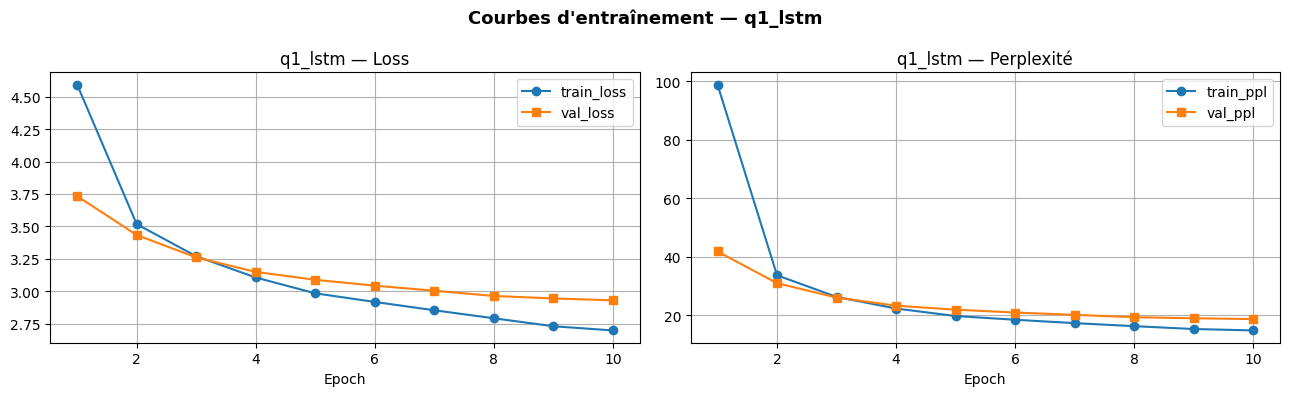

📊 Courbe sauvegardée → /content/drive/MyDrive/Flickr8k_Output/plots/q1_lstm_loss_curve.png


Génération:   0%|          | 0/5 [00:00<?, ?it/s]

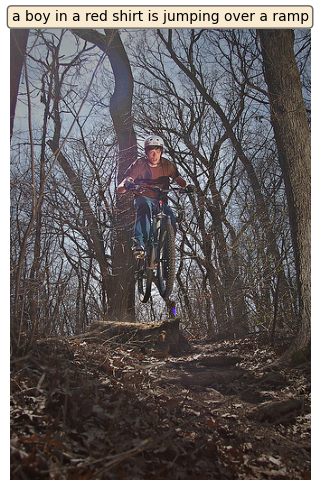

Génération:  20%|██        | 1/5 [00:00<00:03,  1.06it/s]

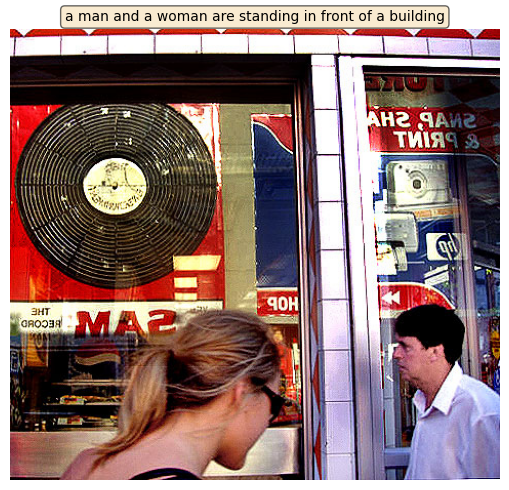

Génération:  40%|████      | 2/5 [00:01<00:02,  1.12it/s]

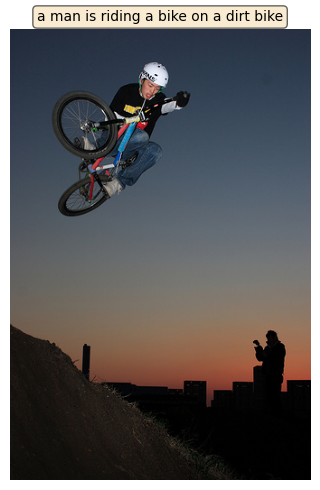

Génération:  60%|██████    | 3/5 [00:02<00:01,  1.25it/s]

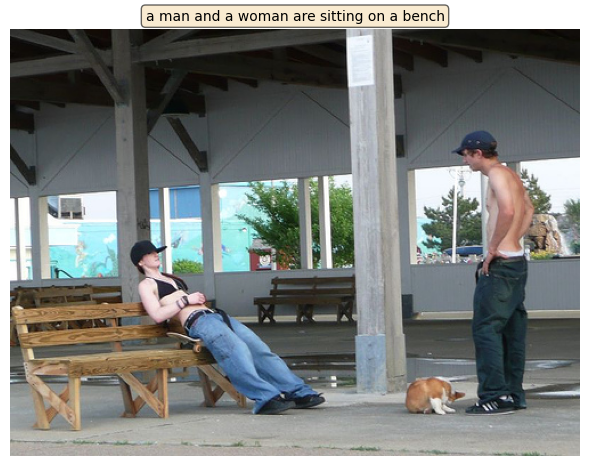

Génération:  80%|████████  | 4/5 [00:03<00:00,  1.21it/s]

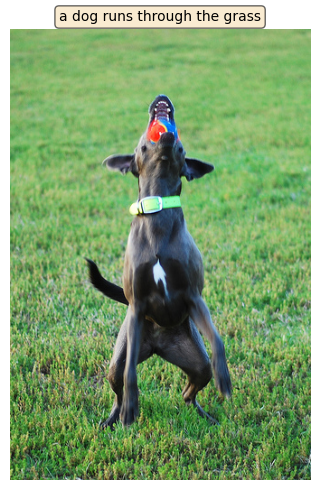

Génération: 100%|██████████| 5/5 [00:04<00:00,  1.19it/s]


📄 Captions sauvegardées → /content/drive/MyDrive/Flickr8k_Output/results/q1_lstm_generated_captions.txt

🔎 Exemples de résultats :
  3435233065_3411f2d29d.jpg: a boy in a red shirt is jumping over a ramp
  428483413_b9370baf72.jpg: a man and a woman are standing in front of a building
  3355756569_b430a29c2a.jpg: a man is riding a bike on a dirt bike
  532457586_bddfc5251d.jpg: a man and a woman are sitting on a bench
  3436313241_6c73153fb6.jpg: a dog runs through the grass


[('3435233065_3411f2d29d.jpg', 'a boy in a red shirt is jumping over a ramp'),
 ('428483413_b9370baf72.jpg',
  'a man and a woman are standing in front of a building'),
 ('3355756569_b430a29c2a.jpg', 'a man is riding a bike on a dirt bike'),
 ('532457586_bddfc5251d.jpg', 'a man and a woman are sitting on a bench'),
 ('3436313241_6c73153fb6.jpg', 'a dog runs through the grass')]

In [ ]:
# ── LSTM (baseline) ─────────────────────────────────────────────
cfg_lstm = {**BASE_CONFIG, 'tag': 'q1_lstm', 'rnn_type': 'lstm'}
hist_lstm = train_model(cfg_lstm)
all_histories['q1_lstm'] = hist_lstm
plot_loss(hist_lstm, 'q1_lstm')
evaluate_on_test('q1_lstm', rnn_type='lstm', n_samples=5)


🚀 Expérience : q1_gru
{
  "tag": "q1_gru",
  "rnn_type": "gru",
  "backbone": "resnet50",
  "embed_size": 256,
  "hidden_size": 512,
  "num_layers": 1,
  "dropout": 0.0,
  "optimizer": "adam",
  "lr": 0.0003,
  "num_epochs": 10,
  "batch_size": 64,
  "save_every": 5
}


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/tmp/ipykernel_1270/3255899679.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None


Epoch [1/10]  Loss: 4.3652  Perplexity: 78.6647  Val_Loss: 3.5843  Val_PPL: 36.0264  (386s)
   🏆 Nouveau meilleur modèle (val_loss=3.5843)


Epoch [2/10]  Loss: 3.3517  Perplexity: 28.5517  Val_Loss: 3.2717  Val_PPL: 26.3548  (383s)
   🏆 Nouveau meilleur modèle (val_loss=3.2717)


Epoch [3/10]  Loss: 3.0833  Perplexity: 21.8295  Val_Loss: 3.1021  Val_PPL: 22.2440  (381s)
   🏆 Nouveau meilleur modèle (val_loss=3.1021)


...

Epoch [6/10]  Loss: 2.6815  Perplexity: 14.6066  Val_Loss: 2.8934  Val_PPL: 18.0543  (387s)
   🏆 Nouveau meilleur modèle (val_loss=2.8934)


Epoch [7/10]  Loss: 2.6103  Perplexity: 13.6034  Val_Loss: 2.8605  Val_PPL: 17.4702  (381s)
   🏆 Nouveau meilleur modèle (val_loss=2.8605)


Epoch [8/10]  Loss: 2.5393  Perplexity: 12.6712  Val_Loss: 2.8229  Val_PPL: 16.8256  (388s)
   🏆 Nouveau meilleur modèle (val_loss=2.8229)


Epoch [9/10]  Loss: 2.4654  Perplexity: 11.7677  Val_Loss: 2.8062  Val_PPL: 16.5464  (387s)
   🏆 Nouveau meilleur modèle (val_loss=2.8062)


Epoch [10/10]  Loss: 2.4291  Perplexity: 11.3491  Val_Loss: 2.7932  Val_PPL: 16.3328  (396s)
   💾 Modèles sauvegardés (epoch 10)
   🏆 Nouveau meilleur modèle (val_loss=2.7932)

✅ Entraînement terminé. Meilleur val_loss=2.7932


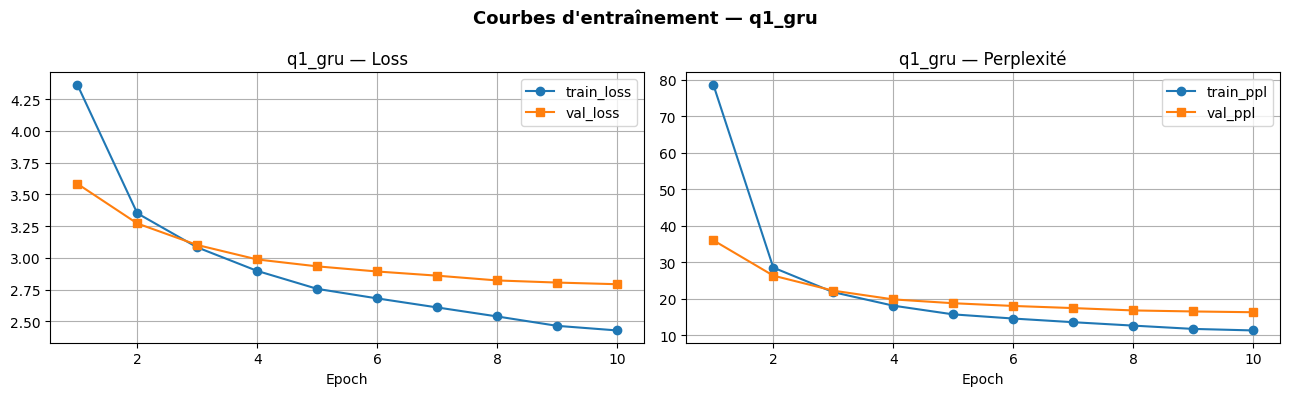

📊 Courbe sauvegardée → /content/drive/MyDrive/Flickr8k_Output/plots/q1_gru_loss_curve.png


Génération:   0%|          | 0/5 [00:00<?, ?it/s]

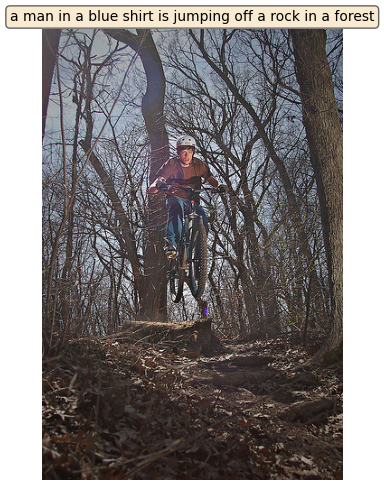

Génération:  20%|██        | 1/5 [00:00<00:01,  2.92it/s]

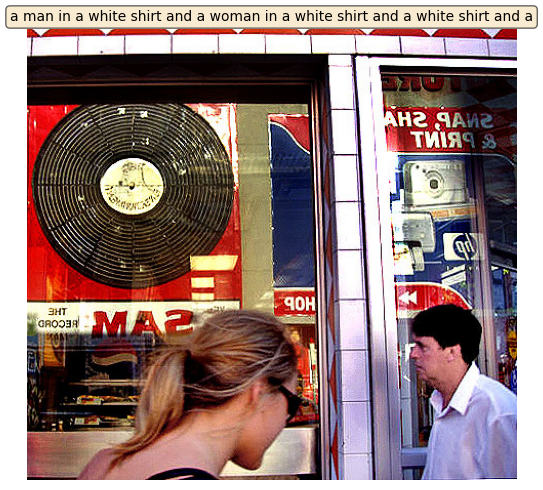

Génération:  40%|████      | 2/5 [00:00<00:01,  2.10it/s]

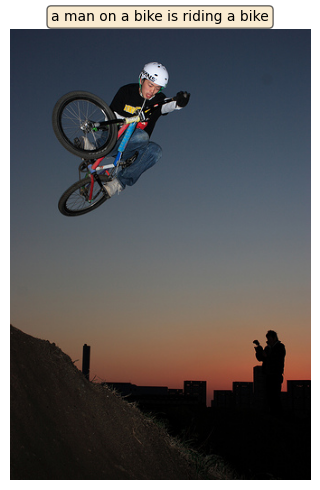

Génération:  60%|██████    | 3/5 [00:01<00:00,  2.53it/s]

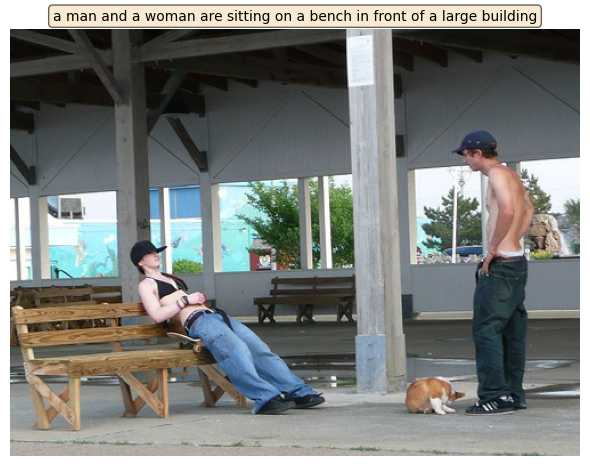

Génération:  80%|████████  | 4/5 [00:01<00:00,  2.25it/s]

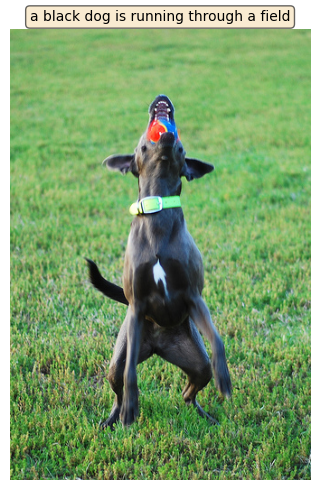

Génération: 100%|██████████| 5/5 [00:02<00:00,  2.44it/s]


📄 Captions sauvegardées → /content/drive/MyDrive/Flickr8k_Output/results/q1_gru_generated_captions.txt

🔎 Exemples de résultats :
  3435233065_3411f2d29d.jpg: a man in a blue shirt is jumping off a rock in a forest
  428483413_b9370baf72.jpg: a man in a white shirt and a woman in a white shirt and a white shirt and a
  3355756569_b430a29c2a.jpg: a man on a bike is riding a bike
  532457586_bddfc5251d.jpg: a man and a woman are sitting on a bench in front of a large building
  3436313241_6c73153fb6.jpg: a black dog is running through a field


[('3435233065_3411f2d29d.jpg',
  'a man in a blue shirt is jumping off a rock in a forest'),
 ('428483413_b9370baf72.jpg',
  'a man in a white shirt and a woman in a white shirt and a white shirt and a'),
 ('3355756569_b430a29c2a.jpg', 'a man on a bike is riding a bike'),
 ('532457586_bddfc5251d.jpg',
  'a man and a woman are sitting on a bench in front of a large building'),
 ('3436313241_6c73153fb6.jpg', 'a black dog is running through a field')]

In [ ]:
# ── GRU ─────────────────────────────────────────────────────────
cfg_gru = {**BASE_CONFIG, 'tag': 'q1_gru', 'rnn_type': 'gru'}
hist_gru = train_model(cfg_gru)
all_histories['q1_gru'] = hist_gru
plot_loss(hist_gru, 'q1_gru')
evaluate_on_test('q1_gru', rnn_type='gru', n_samples=5)


### Q2 — Tailles d'embedding : 128 / 256 / 512 / 1024

In [ ]:
for emb in [128, 256, 512, 1024]:
    tag  = f'q2_emb{emb}'
    cfg  = {**BASE_CONFIG, 'tag': tag, 'embed_size': emb,
            'num_epochs': 5}          # 5 epochs pour comparaison rapide
    hist = train_model(cfg)
    all_histories[tag] = hist
    plot_loss(hist, tag)

compare_experiments({k: v for k, v in all_histories.items()
                     if k.startswith('q2')})


🚀 Expérience : q2_emb128
{
  "tag": "q2_emb128",
  "rnn_type": "lstm",
  "backbone": "resnet50",
  "embed_size": 128,
  "hidden_size": 512,
  "num_layers": 1,
  "dropout": 0.0,
  "optimizer": "adam",
  "lr": 0.0003,
  "num_epochs": 5,
  "batch_size": 64,
  "save_every": 5
}


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
/tmp/ipykernel_1270/3255899679.py:53: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = torch.cuda.amp.GradScaler() if DEVICE.type == 'cuda' else None
Epoch 1/5:  14%|█▍        | 70/506 [00:52<04:40,  1.55it/s]

### Q3 — ResNet18 vs ResNet50

In [ ]:
for bb in ['resnet18', 'resnet50']:
    tag  = f'q3_{bb}'
    cfg  = {**BASE_CONFIG, 'tag': tag, 'backbone': bb}
    hist = train_model(cfg)
    all_histories[tag] = hist
    plot_loss(hist, tag)

compare_experiments({k: v for k, v in all_histories.items()
                     if k.startswith('q3')})


### Q4 — Impact du Dropout

In [ ]:
for dp in [0.0, 0.3, 0.5]:
    tag  = f'q4_drop{int(dp*10)}'
    cfg  = {**BASE_CONFIG, 'tag': tag, 'dropout': dp}
    hist = train_model(cfg)
    all_histories[tag] = hist
    plot_loss(hist, tag)

compare_experiments({k: v for k, v in all_histories.items()
                     if k.startswith('q4')})


### Q5 — Nombre de couches RNN

In [ ]:
for nl in [1, 2, 3]:
    tag  = f'q5_layers{nl}'
    cfg  = {**BASE_CONFIG, 'tag': tag, 'num_layers': nl,
            'dropout': 0.3 if nl > 1 else 0.0}
    hist = train_model(cfg)
    all_histories[tag] = hist
    plot_loss(hist, tag)

compare_experiments({k: v for k, v in all_histories.items()
                     if k.startswith('q5')})


### Q6 — Optimiseur : Adam vs SGD

In [ ]:
for opt, lr in [('adam', 3e-4), ('sgd', 0.05)]:
    tag  = f'q6_{opt}'
    cfg  = {**BASE_CONFIG, 'tag': tag, 'optimizer': opt, 'lr': lr}
    hist = train_model(cfg)
    all_histories[tag] = hist
    plot_loss(hist, tag)

compare_experiments({k: v for k, v in all_histories.items()
                     if k.startswith('q6')})


### 🎁 Travail supplémentaire — CNN + Transformer Decoder

In [ ]:
cfg_transfo = {
    **BASE_CONFIG,
    'tag'       : 'bonus_transformer',
    'rnn_type'  : 'transformer',
    'embed_size': 256,
    'dropout'   : 0.1,
    'num_epochs': 10,
}
hist_transfo = train_model(cfg_transfo)
all_histories['bonus_transformer'] = hist_transfo
plot_loss(hist_transfo, 'bonus_transformer')
evaluate_on_test('bonus_transformer', rnn_type='transformer', n_samples=5)


### 📊 Comparaison Finale : LSTM vs GRU vs Transformer

In [ ]:
# Comparaison des trois architectures principales
compare_experiments({
    k: all_histories[k]
    for k in ['q1_lstm', 'q1_gru', 'bonus_transformer']
    if k in all_histories
})

# Tableau récapitulatif
print(f"\n{'Expérience':<25} {'Meilleure Val Loss':>18} {'Meilleure Val PPL':>18}")
print('-' * 65)
for tag, h in all_histories.items():
    print(f"{tag:<25} {min(h['val_loss']):>18.4f} {min(h['val_ppl']):>18.2f}")

# Sauvegarde du tableau
summary_path = LOGS_DIR / 'experiment_summary.txt'
with open(summary_path, 'w') as f:
    f.write(f"{'Expérience':<25} {'Val Loss':>10} {'Val PPL':>10}\n")
    f.write('-' * 50 + '\n')
    for tag, h in all_histories.items():
        f.write(f"{tag:<25} {min(h['val_loss']):>10.4f} {min(h['val_ppl']):>10.2f}\n")
print(f"\n📋 Résumé sauvegardé → {summary_path}")


---
## 🔍 Partie 7 — Inférence sur une image personnalisée

In [ ]:
# ── Paramètres à adapter ────────────────────────────────────────
INFER_TAG      = 'q1_lstm'           # nom de l'expérience à charger
INFER_RNN_TYPE = 'lstm'              # 'lstm' | 'gru' | 'transformer'
INFER_EPOCH    = 'best'              # 'best' ou numéro d'epoch
EMBED_SIZE     = 256
HIDDEN_SIZE    = 512
IMAGE_PATH     = str(IMAGES_DIR / list(test_imgs)[0])  # ← remplacez par votre image
# IMAGE_PATH   = '/content/drive/MyDrive/mon_image.jpg'

# ── Chargement du modèle ─────────────────────────────────────────
CNN = EncoderCNN(EMBED_SIZE, 'resnet50').to(DEVICE)
if INFER_RNN_TYPE == 'transformer':
    RNN = TransformerCaptionDecoder(EMBED_SIZE, vocab_size).to(DEVICE)
else:
    RNN = DecoderRNN(EMBED_SIZE, HIDDEN_SIZE, vocab_size,
                     rnn_type=INFER_RNN_TYPE).to(DEVICE)

CNN.load_state_dict(torch.load(
    MODELS_DIR / f'{INFER_TAG}_CNN_epoch_{INFER_EPOCH}.pkl',
    map_location=DEVICE))
RNN.load_state_dict(torch.load(
    MODELS_DIR / f'{INFER_TAG}_RNN_epoch_{INFER_EPOCH}.pkl',
    map_location=DEVICE))

# ── Génération ───────────────────────────────────────────────────
caption = caption_image(IMAGE_PATH, CNN, RNN, INFER_RNN_TYPE)

img = Image.open(IMAGE_PATH).convert('RGB')
plt.figure(figsize=(6, 5))
plt.imshow(img); plt.axis('off')
plt.title(f'📝 {caption}', fontsize=12,
          bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
plt.tight_layout()
out_path = RESULTS_DIR / f'inference_{Path(IMAGE_PATH).stem}.jpg'
plt.savefig(out_path, dpi=100, bbox_inches='tight')
plt.show()

print(f"\n✅ Caption générée : {caption}")
print(f"💾 Image sauvegardée → {out_path}")


---
## ⚡ Démarrage rapide — Smoke Test (1 epoch)
> Exécutez cette cellule pour vérifier que tout fonctionne avant de lancer les vraies expériences.


In [ ]:
quick_cfg = {
    **BASE_CONFIG,
    'tag'       : 'smoke_test',
    'num_epochs': 1,
    'batch_size': 32,
}
hist_quick = train_model(quick_cfg)
plot_loss(hist_quick, 'smoke_test')
evaluate_on_test('smoke_test', epoch=1, n_samples=3)
print('\n🎉 Smoke-test OK ! Vérifiez votre Drive pour les sorties.')
